# Training mô hình ResNet50 cho FER2013 (ảnh HR 224×224, Kaggle)

### 1. Khởi tạo môi trường và kiểm tra dataset trên Kaggle


In [1]:

import os
print("Current working directory:", os.getcwd())
print("\nFolders in current directory:")
for item in os.listdir("."):
    if os.path.isdir(item):
        print(f" - {item}/")

# 2) Khai báo đường dẫn dataset FER2013 đã tiền xử lý (HR 224x224)
DATA_DIR = "./FER2013_tien_xu_li"
print("\nDATA_DIR =", DATA_DIR)

# 3) Xem nhanh cấu trúc thư mục bên trong DATA_DIR
print("\nFolders in DATA_DIR:")
if os.path.exists(DATA_DIR):
    for item in os.listdir(DATA_DIR):
        item_path = os.path.join(DATA_DIR, item)
        if os.path.isdir(item_path):
            print(f" - {item}/")
else:
    print(f"❌ ERROR: {DATA_DIR} not found!")

# 4) Kiểm tra phiên bản TensorFlow và cấu hình GPU
import tensorflow as tf
import sys
print("Python:", sys.executable)
print("TF version:", tf.__version__)

# Kích hoạt memory growth để tránh TF chiếm toàn bộ VRAM ngay từ đầu
gpus = tf.config.list_physical_devices('GPU')
print("Danh sách GPU khả dụng:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Đã bật memory growth cho {len(gpus)} GPU.")
        print(f"✅ TensorFlow sẽ sử dụng GPU: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print("⚠️ Lỗi khi cấu hình GPU:", e)
else:
    print("⚠️ Không tìm thấy GPU. Đang chạy trên CPU.")
    print("   → Kernel hiện tại:", sys.executable)
    print("   → Hãy chắc chắn chọn kernel venv39 trong VS Code.")


Current working directory: d:\Github\assigment4_CV

Folders in current directory:
 - .git/
 - .idea/
 - archive/
 - demo/
 - FER2013_tien_xu_li/
 - venv39/

DATA_DIR = ./FER2013_tien_xu_li

Folders in DATA_DIR:
 - test/
 - train/
 - val/
Python: d:\Github\assigment4_CV\venv39\Scripts\python.exe
TF version: 2.10.0
Danh sách GPU khả dụng: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Đã bật memory growth cho 1 GPU.
✅ TensorFlow sẽ sử dụng GPU: ['/physical_device:GPU:0']


### 2. Tạo tf.data.Dataset cho val/train/test dùng để quản lí và xử lí dữ liệu trong quá trình huấn luyện và đánh giá mô hình

Found 97624 files belonging to 7 classes.
Found 4303 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
✅ Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] – num_classes = 7

🔢 Số batch trong từng tập:
 - Số batch train: 3051
 - Số batch val  : 135
 - Số batch test : 225

📊 Số lượng ảnh thực tế:
 - Số ảnh train: 97624
 - Số ảnh val  : 4303
 - Số ảnh test : 7178

🧩 Ví dụ 1 batch từ train_ds:
 - Shape images: (32, 224, 224, 3)
 - Shape labels: (32, 7)

📊 Nhãn one-hot của các ảnh trong batch:
 - Ảnh 0: class index = 5, lớp = sad, one-hot = [0. 0. 0. 0. 0. 1. 0.]
 - Ảnh 1: class index = 2, lớp = fear, one-hot = [0. 0. 1. 0. 0. 0. 0.]
 - Ảnh 2: class index = 4, lớp = neutral, one-hot = [0. 0. 0. 0. 1. 0. 0.]
 - Ảnh 3: class index = 0, lớp = angry, one-hot = [1. 0. 0. 0. 0. 0. 0.]
 - Ảnh 4: class index = 5, lớp = sad, one-hot = [0. 0. 0. 0. 0. 1. 0.]
 - Ảnh 5: class index = 4, lớp = neutral, one-hot = [0. 0. 0. 0. 1. 0. 0.]
 - Ảnh 6: class index

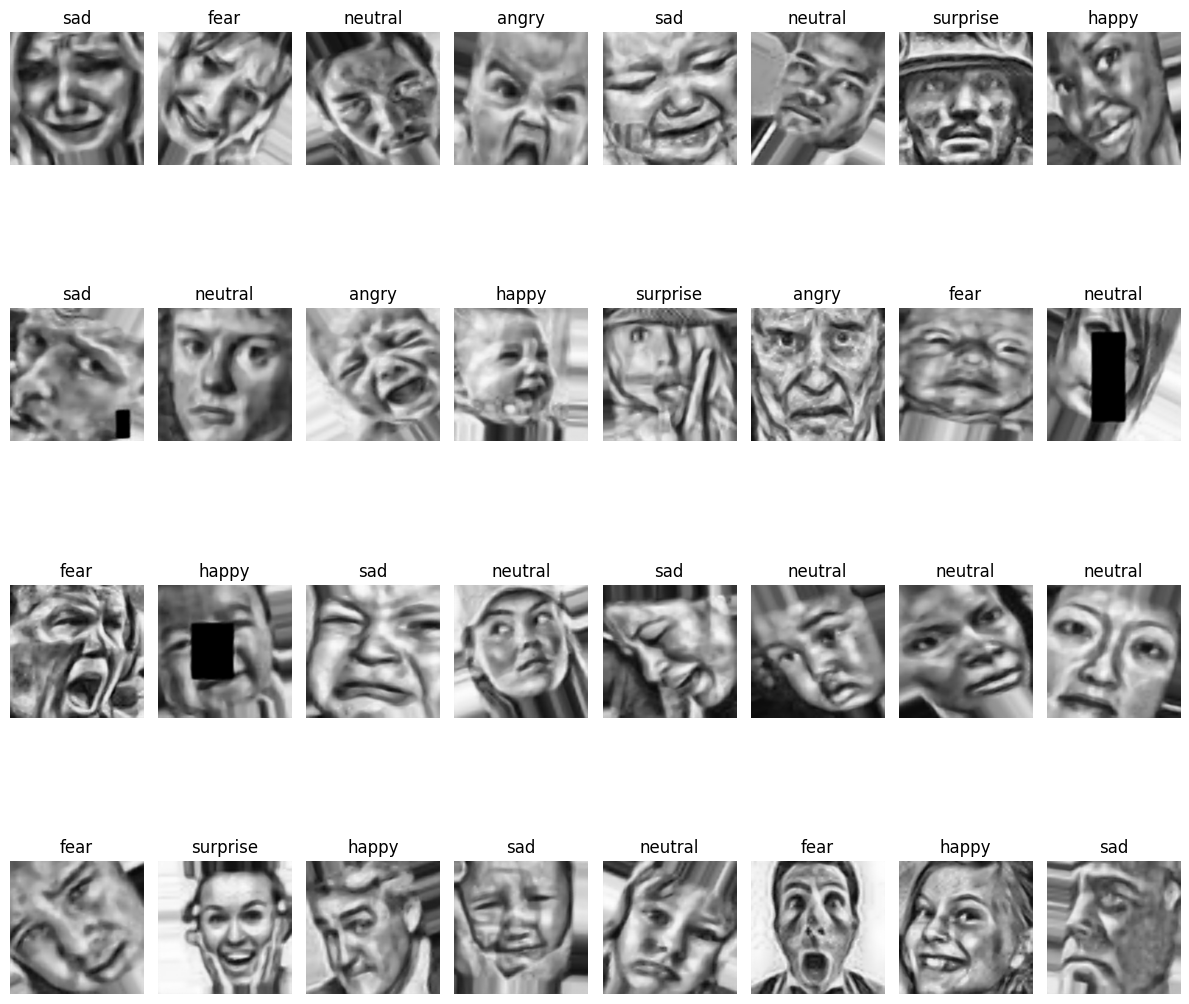

In [2]:
# Cấu hình kích thước ảnh đầu vào, batch size và seed ngẫu nhiên
IMG_SIZE = (224, 224)   # ResNet50 yêu cầu ảnh 224x224
BATCH_SIZE = 32         # Số ảnh / batch khi đưa vào mô hình
SEED = 42               # Seed cố định để việc shuffle tái lập được

# ==========================
# 1. Tạo tf.data.Dataset cho train / val / test
# ==========================

# Tập TRAIN
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,          # Resize ảnh về 224x224
    color_mode="rgb",             # 3 kênh màu RGB (phù hợp ResNet50)
    batch_size=BATCH_SIZE,
    label_mode="categorical",     # Nhãn dạng one-hot cho 7 lớp
    shuffle=True,                 # Shuffle để tránh học theo thứ tự file
    seed=SEED
)

# Tập VALIDATION
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Tập TEST
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# ==========================
# 2. In thông tin tổng quan để đưa vào báo cáo
# ==========================

# Danh sách tên lớp (7 cảm xúc) và số lớp
class_names = train_ds.class_names
num_classes = len(class_names)
print("✅ Classes:", class_names, "– num_classes =", num_classes)

# Số batch trong từng tập (ước lượng nhanh số lượng mẫu)
print("\n🔢 Số batch trong từng tập:")
print(" - Số batch train:", len(train_ds))
print(" - Số batch val  :", len(val_ds))
print(" - Số batch test :", len(test_ds))

# Hàm đếm chính xác số lượng ảnh trong mỗi tập
def count_images(dataset):
    total = 0
    for batch_images, _ in dataset:
        total += batch_images.shape[0]  # batch_size thực tế (batch cuối có thể nhỏ hơn)
    return total

n_train = count_images(train_ds)
n_val   = count_images(val_ds)
n_test  = count_images(test_ds)

print("\n📊 Số lượng ảnh thực tế:")
print(" - Số ảnh train:", n_train)
print(" - Số ảnh val  :", n_val)
print(" - Số ảnh test :", n_test)

# ==========================
# ==========================
# 3. Kiểm tra cấu trúc 1 batch & in toàn bộ ảnh kèm label
# ==========================

for images, labels in train_ds.take(1):
    # images: (BATCH_SIZE, 224, 224, 3), labels: (BATCH_SIZE, 7)
    print("\n🧩 Ví dụ 1 batch từ train_ds:")
    print(" - Shape images:", images.shape)
    print(" - Shape labels:", labels.shape)

    # In ra thông tin nhãn one-hot của từng ảnh trong batch
    print("\n📊 Nhãn one-hot của các ảnh trong batch:")
    for i in range(images.shape[0]):  # Duyệt qua tất cả ảnh trong batch
        label_vec = labels[i].numpy()
        class_idx = int(tf.argmax(label_vec).numpy())  # Lấy index lớp từ one-hot vector
        class_name = class_names[class_idx]  # Lấy tên lớp tương ứng
        print(f" - Ảnh {i}: class index = {class_idx}, lớp = {class_name}, one-hot = {label_vec}")

    # Hiển thị tất cả ảnh trong batch
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 12))
    for i in range(images.shape[0]):
        ax = plt.subplot(4, 8, i + 1)  # Chia lưới ảnh 4x4, có thể điều chỉnh
        img = images[i].numpy().astype("uint8")
        label_vec = labels[i].numpy()
        class_idx = int(tf.argmax(label_vec).numpy())
        class_name = class_names[class_idx]

        plt.imshow(img)  # Hiển thị ảnh
        plt.title(class_name)  # Ghi tên lớp lên trên ảnh
        plt.axis("off")  # Tắt trục

    plt.tight_layout()  # Căn chỉnh lại layout cho đẹp
    plt.show()
    break   # Chỉ lấy đúng 1 batch


    


### 3.Chuẩn hóa ảnh theo chuẩn của Imagenet

In [3]:
# Import hàm preprocess_input từ ResNet50, dùng để tiền xử lý ảnh cho phù hợp với mô hình ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Cấu hình AUTOTUNE giúp TensorFlow tự động tối ưu hóa việc tải dữ liệu
AUTOTUNE = tf.data.AUTOTUNE

# Định nghĩa hàm preprocess để chuẩn hóa ảnh và nhãn
def preprocess(img, label):
    img = tf.cast(img, tf.float32)  # Chuyển ảnh sang kiểu float32 để có thể xử lý
    img = preprocess_input(img)     # Tiền xử lý ảnh theo chuẩn của ResNet50 (mean subtraction)
    return img, label

# Áp dụng hàm preprocess cho các tập train, validation và test
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Lấy 1 batch ảnh từ train_ds để kiểm tra sau khi preprocess
for images, labels in train_ds.take(1):
    img = images[0].numpy()   # Lấy ảnh đầu tiên trong batch và chuyển thành numpy array
    label = labels[0].numpy()  # Lấy nhãn (one-hot) tương ứng với ảnh đầu tiên

    # In ra nhãn one-hot của ảnh đầu tiên
    print("🔹 Label one-hot:", label)
    # In ra kích thước của ảnh
    print("🔹 Shape ảnh:", img.shape)  # (224, 224, 3)

    # In ra ma trận 5x5 đầu tiên của kênh R (Red) trong ảnh
    print("\n🔹 Ma trận 5x5 đầu tiên (kênh R):")
    print(img[:5, :5, 0])

    # In ra ma trận 5x5 đầu tiên của kênh G (Green) trong ảnh
    print("\n🔹 Ma trận 5x5 đầu tiên (kênh G):")
    print(img[:5, :5, 1])

    # In ra ma trận 5x5 đầu tiên của kênh B (Blue) trong ảnh
    print("\n🔹 Ma trận 5x5 đầu tiên (kênh B):")
    print(img[:5, :5, 2])


🔹 Label one-hot: [0. 0. 0. 0. 1. 0. 0.]
🔹 Shape ảnh: (224, 224, 3)

🔹 Ma trận 5x5 đầu tiên (kênh R):
[[26.060997 30.060997 32.060997 33.060997 35.060997]
 [26.060997 32.060997 36.060997 37.060997 38.060997]
 [23.060997 31.060997 36.060997 37.060997 39.060997]
 [12.060997 20.060997 26.060997 29.060997 32.060997]
 [-3.939003  3.060997  9.060997 13.060997 19.060997]]

🔹 Ma trận 5x5 đầu tiên (kênh G):
[[ 13.221001    17.221       19.221       20.221       22.221     ]
 [ 13.221001    19.221       23.221       24.221       25.221     ]
 [ 10.221001    18.221       23.221       24.221       26.221     ]
 [ -0.7789993    7.2210007   13.221001    16.221       19.221     ]
 [-16.779       -9.778999    -3.7789993    0.22100067   6.2210007 ]]

🔹 Ma trận 5x5 đầu tiên (kênh B):
[[  6.3199997  10.32       12.32       13.32       15.32     ]
 [  6.3199997  12.32       16.32       17.32       18.32     ]
 [  3.3199997  11.32       16.32       17.32       19.32     ]
 [ -7.6800003   0.3199997   6.31999

### 4.Xây dựng mô hình phân loại cảm xúc với ResNet50.



In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

# Tải mô hình ResNet50 đã được huấn luyện trên ImageNet mà không có phần fully connected (FC) cuối
base_model = ResNet50(
    weights='imagenet',  # Sử dụng pre-trained weights từ ImageNet (tải tự động)
    include_top=False,   # Bỏ phần FC cuối cùng của ImageNet (tránh overfitting trên dataset nhỏ hơn)
    input_shape=(224, 224, 3)  # Định dạng đầu vào là ảnh 224x224 với 3 kênh (RGB)
)

# Giai đoạn 1: Không cập nhật trọng số của ResNet
base_model.trainable = False  # Khóa các trọng số của mô hình ResNet, giữ nguyên các trọng số đã học

# Định nghĩa đầu vào của mô hình (ảnh có kích thước 224x224 và 3 kênh màu)
inputs = tf.keras.Input(shape=(224, 224, 3))

# Đưa ảnh vào mô hình ResNet (không train trọng số của base_model)
x = base_model(inputs, training=False)  # Pass input qua base_model, không huấn luyện trong giai đoạn này

# Sử dụng Global Average Pooling để giảm chiều của feature map (lấy trung bình các giá trị)
x = layers.GlobalAveragePooling2D()(x)  # Chuyển feature map thành vector 1 chiều

# Áp dụng Dropout để giảm overfitting (tỉ lệ dropout là 0.3)
x = layers.Dropout(0.3)(x)

# Thêm lớp Dense cuối cùng với số lượng lớp bằng số lớp cảm xúc (num_classes)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Tạo mô hình kết hợp các lớp trên (inputs và outputs)
model = models.Model(inputs, outputs)

# Định nghĩa hàm mất mát và tối ưu hóa cho mô hình
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0)  # Hàm mất mát với Categorical Crossentropy
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)  # Adam optimizer với learning rate nhỏ

# Biên dịch mô hình với hàm mất mát và tối ưu hóa đã định nghĩa
model.compile(
    optimizer=optimizer,  # Sử dụng optimizer Adam
    loss=loss_fn,  # Hàm mất mát CategoricalCrossentropy
    metrics=["accuracy"]  # Đo lường độ chính xác (accuracy)
)

# In ra thông tin mô hình (số lượng lớp, tham số, v.v.)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 7)                 14343     
                                                                 
Total params: 23,602,055
Trainable params: 14,343
Non-trainable params: 23,587,712
____________________________________________

### 5.Tính toán trọng số lớp (Class Weights) cho dữ liệu không cân bằng.

In [5]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

num_classes = 7  # Số lớp trong bài toán phân loại (hoặc có thể thay bằng len(EMOTIONS) / len(class_names))

all_labels = []  # Danh sách chứa tất cả nhãn lớp từ dữ liệu huấn luyện

# Duyệt qua toàn bộ tập huấn luyện (train_ds)
for images, labels in train_ds:
    # labels hiện là one-hot vector: (batch_size, num_classes)
    labels_idx = np.argmax(labels.numpy(), axis=1)  # Chuyển từ one-hot về chỉ số lớp (index) -> [batch_size]
    all_labels.extend(labels_idx)  # Thêm các chỉ số lớp vào danh sách

all_labels = np.array(all_labels)  # Chuyển all_labels thành một mảng numpy

# Tính toán trọng số các lớp bằng phương pháp 'balanced' (cân bằng)
class_weights = compute_class_weight(
    class_weight="balanced",  # Tính trọng số cân bằng cho mỗi lớp
    classes=np.arange(num_classes),  # Các lớp là các số nguyên từ 0 đến num_classes-1
    y=all_labels  # Dữ liệu nhãn của tất cả các ảnh trong tập huấn luyện
)

# Chuẩn hóa trọng số lớp sao cho giá trị trung bình = 1
class_weights = class_weights / class_weights.mean()   # Đảm bảo trọng số trung bình là 1

# Giới hạn trọng số lớp tối đa là 3.0 để tránh ảnh hưởng quá lớn từ lớp ít xuất hiện
class_weights = np.minimum(class_weights, 3.0)         # Giới hạn trọng số tối đa là 3.0

# Chuyển trọng số thành dictionary, với key là chỉ số lớp và value là trọng số của lớp đó
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

# In ra trọng số lớp
print("Class weights:", class_weights_dict)

Class weights: {0: 0.48031856877904827, 1: 3.0, 2: 0.46832094733667745, 3: 0.2659647577977577, 4: 0.38643967296224774, 5: 0.39726299551233507, 6: 0.6050303633433411}


### 6.Hàm đánh giá quá trình train

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def summarize_training(history, model, train_ds, val_ds, stage_name="Stage"):
    train_loss = history.history["loss"]
    val_loss   = history.history["val_loss"]
    train_acc  = history.history["accuracy"]
    val_acc    = history.history["val_accuracy"]

    epochs = len(train_loss)

    print(f"\n===================================================================")
    print(f"📈 TỔNG KẾT KẾT QUẢ TRAINING – {stage_name}")
    print("===================================================================\n")

    print(f"Số epochs train thực tế: {epochs}\n")

    print("Kết quả epoch cuối cùng (train):")
    print(f" - Loss      : {train_loss[-1]:.4f}")
    print(f" - Accuracy  : {train_acc[-1]*100:.2f}%\n")

    print("Kết quả epoch cuối cùng (validation):")
    print(f" - Val Loss  : {val_loss[-1]:.4f}")
    print(f" - Val Acc   : {val_acc[-1]*100:.2f}%\n")

    print("Best results trong quá trình training:")
    print(f" - Best Train Acc   : {max(train_acc):.4f} tại epoch {np.argmax(train_acc)}")
    print(f" - Lowest Train Loss: {min(train_loss):.4f} tại epoch {np.argmin(train_loss)}")
    print(f" - Best Val Acc     : {max(val_acc):.4f} tại epoch {np.argmax(val_acc)}")
    print(f" - Lowest Val Loss  : {min(val_loss):.4f} tại epoch {np.argmin(val_loss)}\n")

    # Vẽ biểu đồ Loss & Accuracy
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(train_loss, label="Train Loss")
    ax[0].plot(val_loss, label="Val Loss")
    ax[0].set_title(f"Loss ({stage_name})")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(train_acc, label="Train Acc")
    ax[1].plot(val_acc, label="Val Acc")
    ax[1].set_title(f"Accuracy ({stage_name})")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.show()

    # Phân tích over/under fitting nhanh
    diff_acc = train_acc[-1] - val_acc[-1]
    diff_loss = val_loss[-1] - train_loss[-1]

    print("Phân tích overfitting/underfitting (epoch cuối):")
    print(f" - Chênh lệch Acc (train - val): {diff_acc:.4f}")
    print(f" - Chênh lệch Loss (val - train): {diff_loss:.4f}")

    if diff_acc > 0.1:
        print(" 👉 Mô hình có dấu hiệu overfitting.")
    elif diff_acc < -0.05:
        print(" 👉 Mô hình có dấu hiệu underfitting (val tốt hơn train).")
    else:
        print(" 👉 Mô hình khá cân bằng giữa train và val.")

    # ============================
    # Đánh giá trên tập Validation
    # ============================
    print("\n===============================")
    print("📊 Đánh giá trên tập Validation")
    print("===============================")
    
    # Dự đoán trên tập validation
    val_preds = model.predict(val_ds, batch_size=32, verbose=1)
    val_preds = np.argmax(val_preds, axis=1)

    val_labels = []
    for images, labels in val_ds:
        val_labels.extend(np.argmax(labels.numpy(), axis=1))

    val_labels = np.array(val_labels)

    # Precision, Recall, F1-Score
    precision = precision_score(val_labels, val_preds, average="weighted")
    recall = recall_score(val_labels, val_preds, average="weighted")
    f1 = f1_score(val_labels, val_preds, average="weighted")

    print(f" - Precision   : {precision:.4f}")
    print(f" - Recall      : {recall:.4f}")
    print(f" - F1-Score    : {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Validation)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


### 7.Freeze Backbone và Huấn luyện Bộ phân loại (Head)

Epoch 1/50
3051/3051 [==============================] - ETA: 0s - loss: 0.8159 - accuracy: 0.3234
Epoch 1: val_accuracy improved from -inf to 0.45968, saving model to .\fer_resnet_best_stage1.h5
3051/3051 [==============================] - 138s 44ms/step - loss: 0.8159 - accuracy: 0.3234 - val_loss: 1.4498 - val_accuracy: 0.4597 - lr: 2.0000e-04
Epoch 2/50
3050/3051 [============================>.] - ETA: 0s - loss: 0.7214 - accuracy: 0.3983
Epoch 2: val_accuracy improved from 0.45968 to 0.48640, saving model to .\fer_resnet_best_stage1.h5
3051/3051 [==============================] - 131s 43ms/step - loss: 0.7214 - accuracy: 0.3983 - val_loss: 1.3899 - val_accuracy: 0.4864 - lr: 2.0000e-04
Epoch 3/50
3051/3051 [==============================] - ETA: 0s - loss: 0.6984 - accuracy: 0.4132
Epoch 3: val_accuracy did not improve from 0.48640
3051/3051 [==============================] - 131s 43ms/step - loss: 0.6984 - accuracy: 0.4132 - val_loss: 1.3791 - val_accuracy: 0.4806 - lr: 2.0000e-04

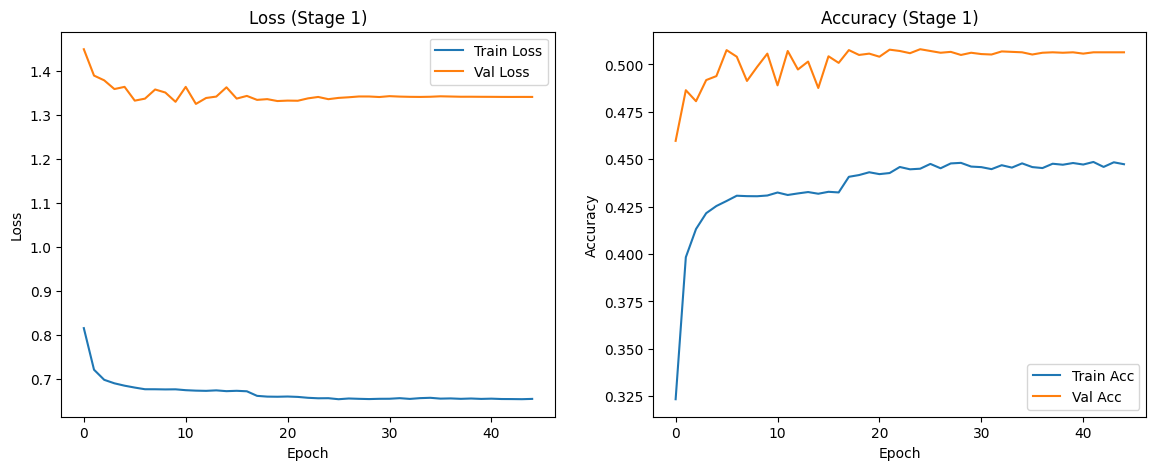

Phân tích overfitting/underfitting (epoch cuối):
 - Chênh lệch Acc (train - val): -0.0590
 - Chênh lệch Loss (val - train): 0.6863
 👉 Mô hình có dấu hiệu underfitting (val tốt hơn train).

📊 Đánh giá trên tập Validation
135/135 [==============================] - 6s 40ms/step
 - Precision   : 0.5097
 - Recall      : 0.5080
 - F1-Score    : 0.5053


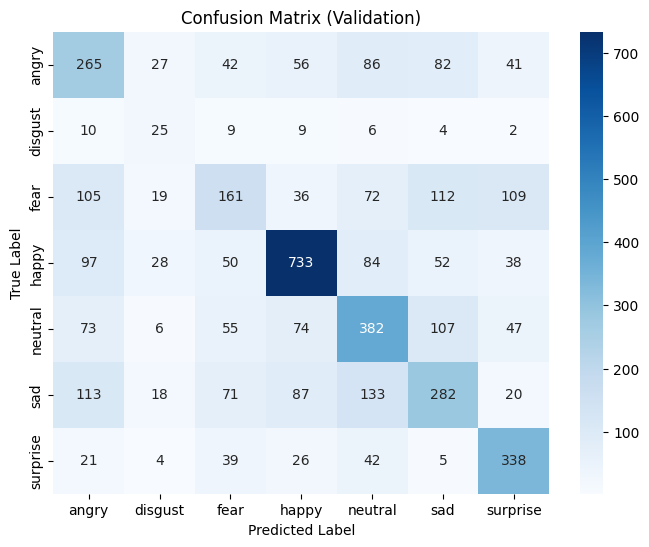

In [7]:
# Import các callback cần thiết từ Keras
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Đường dẫn để lưu trọng số mô hình tốt nhất (đường dẫn local)
CHECKPOINT_PATH = "./fer_resnet_best_stage1.h5"

# Định nghĩa các callback dùng trong quá trình huấn luyện
callbacks = [
    # ModelCheckpoint lưu mô hình tốt nhất dựa trên validation accuracy
    ModelCheckpoint(
        CHECKPOINT_PATH,                # Đường dẫn để lưu mô hình
        monitor="val_accuracy",         # Theo dõi validation accuracy để lưu mô hình tốt nhất
        mode="max",                     # Chọn mô hình có validation accuracy cao nhất
        save_best_only=True,            # Chỉ lưu mô hình tốt nhất
        save_weights_only=False,        # Lưu cả mô hình và trọng số (không chỉ trọng số)
        verbose=1                        # In ra thông tin mỗi khi mô hình được lưu
    ),
    # ReduceLROnPlateau giảm learning rate khi validation loss không cải thiện sau số epoch nhất định
    ReduceLROnPlateau(
        monitor="val_loss",             # Theo dõi validation loss
        factor=0.25,                    # Giảm learning rate xuống còn 25% mỗi khi không cải thiện
        patience=5,                     # Chờ 5 epoch mà validation loss không cải thiện
        verbose=1                       # In ra thông tin mỗi khi learning rate được giảm
    ),
    # EarlyStopping dừng huấn luyện nếu validation accuracy không cải thiện trong một thời gian dài
    EarlyStopping(
        monitor="val_accuracy",         # Theo dõi validation accuracy
        mode="max",                     # Dừng nếu validation accuracy không cải thiện
        patience=20,                    # Dừng sau 20 epoch mà không có sự cải thiện
        restore_best_weights=True,      # Khôi phục trọng số của mô hình tốt nhất sau khi dừng
        verbose=1                        # In ra thông tin khi huấn luyện dừng
    )
]

# Số lượng epoch cho giai đoạn 1, có thể điều chỉnh nếu cần
EPOCHS_1 = 50  # Có thể tăng lên nếu thấy mô hình chưa hội tụ

# Bắt đầu huấn luyện mô hình
history_1 = model.fit(
    train_ds,                           # Dữ liệu huấn luyện
    validation_data=val_ds,             # Dữ liệu validation
    epochs=EPOCHS_1,                    # Số lượng epoch
    callbacks=callbacks,                # Sử dụng các callback đã định nghĩa
    class_weight=class_weights_dict     # Trọng số các lớp để xử lý mất cân bằng
)

# Tổng kết kết quả huấn luyện và vẽ biểu đồ, phân tích overfitting/underfitting
summarize_training(history_1, model, train_ds, val_ds, stage_name="Stage 1")

### 8.Huấn luyện Fine-tune với một phần mô hình ResNet

Epoch 1/50
3050/3051 [============================>.] - ETA: 0s - loss: 0.7075 - accuracy: 0.4449
Epoch 1: val_accuracy improved from -inf to 0.50639, saving model to .\fer_resnet_best_finetune.h5
3051/3051 [==============================] - 140s 45ms/step - loss: 0.7075 - accuracy: 0.4449 - val_loss: 1.4658 - val_accuracy: 0.5064 - lr: 1.0000e-05
Epoch 2/50
3051/3051 [==============================] - ETA: 0s - loss: 0.7075 - accuracy: 0.4420
Epoch 2: val_accuracy improved from 0.50639 to 0.50709, saving model to .\fer_resnet_best_finetune.h5
3051/3051 [==============================] - 137s 45ms/step - loss: 0.7075 - accuracy: 0.4420 - val_loss: 1.4673 - val_accuracy: 0.5071 - lr: 1.0000e-05
Epoch 3/50
3051/3051 [==============================] - ETA: 0s - loss: 0.7065 - accuracy: 0.4421
Epoch 3: val_accuracy improved from 0.50709 to 0.50895, saving model to .\fer_resnet_best_finetune.h5
3051/3051 [==============================] - 137s 45ms/step - loss: 0.7065 - accuracy: 0.4421 - v

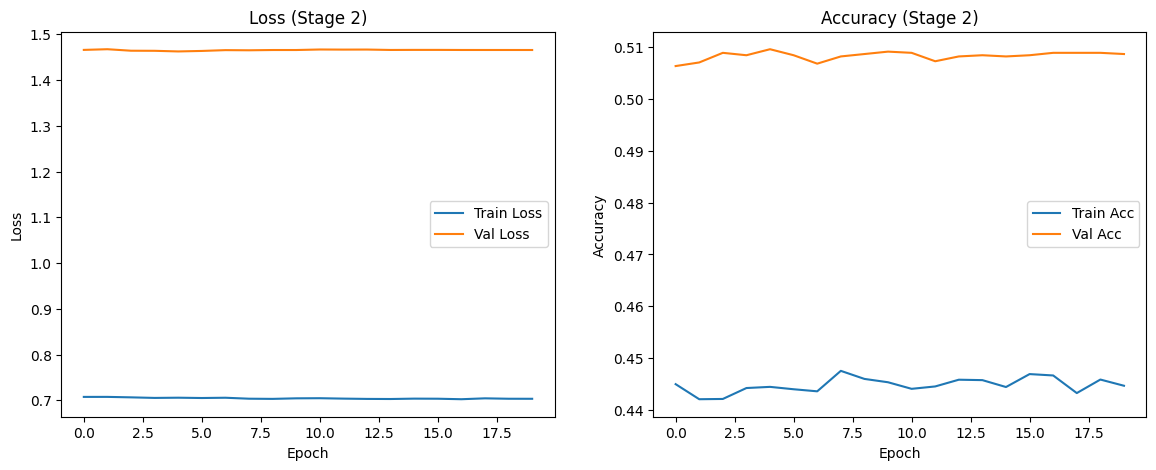

Phân tích overfitting/underfitting (epoch cuối):
 - Chênh lệch Acc (train - val): -0.0641
 - Chênh lệch Loss (val - train): 0.7622
 👉 Mô hình có dấu hiệu underfitting (val tốt hơn train).

📊 Đánh giá trên tập Validation
135/135 [==============================] - 6s 41ms/step
 - Precision   : 0.5107
 - Recall      : 0.5096
 - F1-Score    : 0.5058


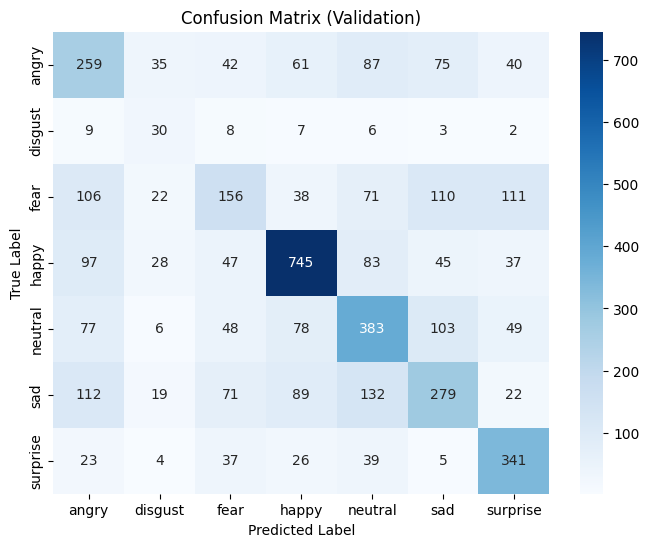

In [8]:
fine_tune_at = 160   # ví dụ mở từ layer 160 trở đi, bạn có thể chỉnh

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

CHECKPOINT_PATH_FT = "./fer_resnet_best_finetune.h5"

callbacks_ft = [
    ModelCheckpoint(
        CHECKPOINT_PATH_FT,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=3,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

EPOCHS_2 = 50

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_2,
    callbacks=callbacks_ft,
    class_weight=class_weights_dict
)
summarize_training(history_2, model, train_ds, val_ds, stage_name="Stage 2")

### 9.Đánh giá mô hình sau khi train trên tập test

225/225 [==============================] - 10s 42ms/step - loss: 1.4729 - accuracy: 0.5011

🎯 Kết quả trên TEST SET:
 - Test Loss: 1.4729
 - Test Acc : 50.11%
225/225 [==============================] - 9s 41ms/step

📊 Các chỉ số đánh giá chi tiết trên TEST set:
 - Precision   : 0.5027
 - Recall      : 0.5011
 - F1-Score    : 0.4981


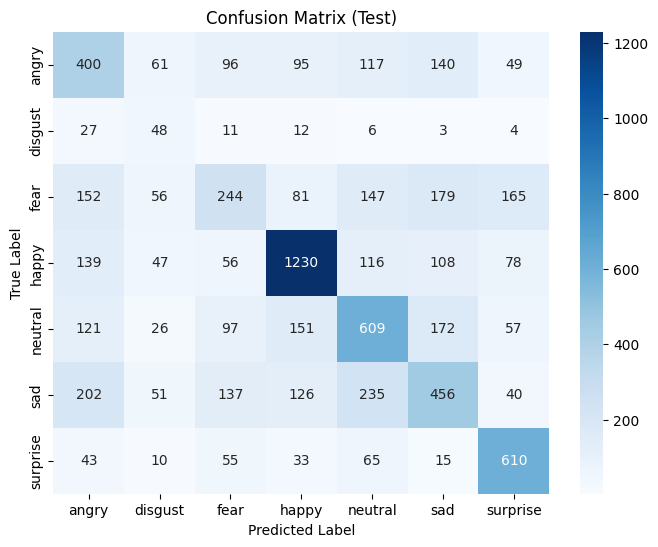


📈 Phân tích overfitting/underfitting (test vs. validation):
 - Chênh lệch Acc (test - val): -0.0085
 👉 Mô hình khá cân bằng giữa test và val.


In [9]:
# Giả sử bạn đã có giá trị val_acc từ quá trình huấn luyện
val_acc = history_2.history['val_accuracy']

# Đánh giá mô hình trên test set
test_loss, test_acc = model.evaluate(test_ds)
print("\n🎯 Kết quả trên TEST SET:")
print(f" - Test Loss: {test_loss:.4f}")
print(f" - Test Acc : {test_acc*100:.2f}%")

# ============================
# Đánh giá chi tiết với các chỉ số khác
# ============================
# Dự đoán trên tập test
test_preds = model.predict(test_ds, batch_size=32, verbose=1)
test_preds = np.argmax(test_preds, axis=1)

# Lấy nhãn thật từ test_ds
test_labels = []
for images, labels in test_ds:
    test_labels.extend(np.argmax(labels.numpy(), axis=1))
test_labels = np.array(test_labels)

# Precision, Recall, F1-Score
precision = precision_score(test_labels, test_preds, average="weighted")
recall = recall_score(test_labels, test_preds, average="weighted")
f1 = f1_score(test_labels, test_preds, average="weighted")

print("\n📊 Các chỉ số đánh giá chi tiết trên TEST set:")
print(f" - Precision   : {precision:.4f}")
print(f" - Recall      : {recall:.4f}")
print(f" - F1-Score    : {f1:.4f}")

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Phân tích over/under fitting nhanh trên test set
diff_acc = test_acc - max(val_acc)  # So sánh với val_accuracy cao nhất

print("\n📈 Phân tích overfitting/underfitting (test vs. validation):")
print(f" - Chênh lệch Acc (test - val): {diff_acc:.4f}")

if diff_acc > 0.1:
    print(" 👉 Mô hình có dấu hiệu overfitting.")
elif diff_acc < -0.05:
    print(" 👉 Mô hình có dấu hiệu underfitting (test tốt hơn val).")
else:
    print(" 👉 Mô hình khá cân bằng giữa test và val.")
